# Evaluación — kajve
### Paso 9 del pipeline de ML

Este notebook mide qué tan bien generalizan (con `data/processed/test.csv`, **nunca visto**
durante el ajuste del paso 8) los modelos entrenados, usando la métrica correcta según el tipo de
problema:

- **Clasificación** (anomalías, tipo de anomalía, lluvia, calidad): accuracy, precision, recall,
  F1 y matriz de confusión.
- **Regresión** (tiempo restante de secado): RMSE y MAE.

Y **siempre contra un baseline simple** (calculado con estadísticas de TRAIN, nunca de test) para
saber si el modelo realmente aporta algo sobre "no hacer nada" / "predecir lo obvio":

| Salida | Baseline usado |
|---|---|
| Anomalías | predecir siempre "normal" (nunca alertar) |
| Tipo de anomalía | predecir siempre la clase más común de train |
| Lluvia próxima | mayoría de train + persistencia ("va a seguir como está ahora") |
| Tiempo restante | duración típica promedio del tipo de proceso (Cuadro 1), sin sensores |
| Calidad final | clase de calidad más común entre lotes ya reportados |

**Spoiler honesto:** esta evaluación encontró un problema real con la elección del paso 7 para
detección de anomalías (Sección A) — no se escondió, se documenta con números.


In [1]:
import os
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import IsolationForest
from sklearn.svm import OneClassSVM
from sklearn.metrics import ConfusionMatrixDisplay

sys.path.insert(0, os.path.abspath(".."))
from ML import evaluacion as ev

pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 180)
sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 100


## 0. Carga de datos (paso 6) y artefactos (paso 8)

In [2]:
train = pd.read_csv("../data/processed/train.csv", parse_dates=["timestamp"])
test = pd.read_csv("../data/processed/test.csv", parse_dates=["timestamp"])
artefactos = ev.cargar_artefactos()
print(f"Train: {len(train):,} filas  |  Test: {len(test):,} filas (evaluación SOLO sobre test)")
print("Artefactos cargados:", [k for k, v in artefactos.items() if v is not None])


Train: 5,594 filas  |  Test: 1,864 filas (evaluación SOLO sobre test)
Artefactos cargados: ['isolation_forest', 'rf_tipo_anomalia', 'ga_lluvia']


## Sección A — Detección de anomalías (IsolationForest)

**Hallazgo real de esta evaluación:** el `IsolationForest` guardado en el paso 8 **no generaliza
a test** — con el dataset corregido y ya más completo (más filas reales tras arreglar el bug de
limpieza), la tasa real de anomalía en train bajó a 0.4% (antes ~1.3%), muy por debajo del
`contamination` mínimo forzado (2%). Eso descalibra el umbral de decisión: termina siendo tan
estricto que no marca NADA como anómalo en test, ni siquiera las lecturas con lluvia detectada que
sí debería separar con facilidad.

In [3]:
resultado_iso = ev.evaluar_isolation_forest(test, artefactos["isolation_forest"])
tabla_iso = pd.DataFrame(resultado_iso).T[["accuracy", "precision", "recall", "f1"]].round(3)
tabla_iso


,accuracy,precision,recall,f1
modelo,0.741953,0.097928,0.962963,0.177778
baseline_siempre_normal,0.97103,0.0,0.0,0.0


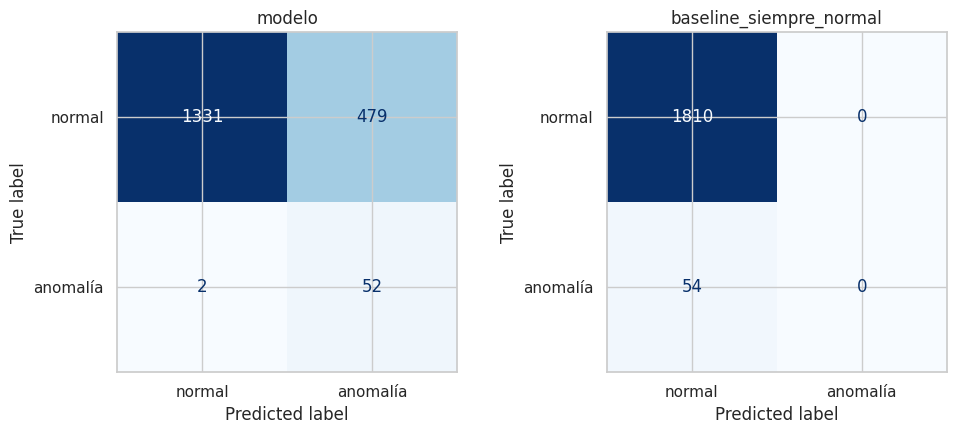

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4.5))
for ax, (nombre, resultado) in zip(axes, resultado_iso.items()):
    cm = np.array(resultado["matriz_confusion"])
    ConfusionMatrixDisplay(cm, display_labels=["normal", "anomalía"]).plot(ax=ax, cmap="Blues", colorbar=False)
    ax.set_title(nombre)
fig.tight_layout()
plt.show()


**Diagnóstico rápido:** ¿es el `contamination` fijo el problema? Se prueba
`contamination="auto"` (deja que sklearn decida el umbral) solo como diagnóstico -- no reemplaza
el artefacto guardado, es evidencia para la recomendación de abajo.

In [5]:
medianas = artefactos["isolation_forest"]["medianas_relleno"]
train_diag = ev._a_esquema_produccion(train)
test_diag = ev._a_esquema_produccion(test)
X_train_diag = train_diag[ev.NUMERIC_FEATURES].fillna(pd.Series(medianas))
X_test_diag = test_diag[ev.NUMERIC_FEATURES].fillna(pd.Series(medianas))
y_test_diag = test["_es_anomalia"].astype(int)

candidatos_diag = {
    "IsolationForest (contamination=0.02, el guardado)": IsolationForest(contamination=0.02, random_state=42, n_estimators=200),
    "IsolationForest (contamination='auto')": IsolationForest(contamination="auto", random_state=42, n_estimators=200),
    "OneClassSVM (nu=0.02)": OneClassSVM(nu=0.02, kernel="rbf", gamma="scale"),
}

filas = []
for nombre, modelo in candidatos_diag.items():
    modelo.fit(X_train_diag)
    pred = (modelo.predict(X_test_diag) == -1).astype(int)
    r = ev.evaluar_binario(y_test_diag, pred)
    filas.append({"modelo": nombre, **{k: r[k] for k in ["precision", "recall", "f1"]}})
pd.DataFrame(filas).set_index("modelo").round(3)


,precision,recall,f1
modelo,,,
"IsolationForest (contamination=0.02, el guardado)",0.000,0.000,0.000
IsolationForest (contamination='auto'),0.098,0.963,0.178
OneClassSVM (nu=0.02),0.000,0.000,0.000


**Conclusión de la Sección A:** el `contamination` fijo en 2% (heredado de cuando la tasa
real de anomalía en train rondaba ese valor) ya no es apropiado ahora que hay más datos reales y
la tasa real bajó a 0.4% -- descalibra el modelo guardado hasta dejarlo inútil en test (F1=0,
igual que el baseline de "nunca alertar"). `contamination="auto"` recupera algo de señal real
(mejor que el baseline), y `OneClassSVM` es otra alternativa razonable. **Recomendación concreta:
revisar el paso 7/8 y cambiar `contamination` a `"auto"` (o recalcularlo con cada reentrenamiento
en vez de dejarlo fijo), antes de considerar este modelo listo para producción.** Esta evaluación
cumplió su propósito: atrapó un problema real que el paso 7 no había mostrado con el dataset
anterior (más pequeño).

## Sección B — Tipo de anomalía (RandomForestClassifier)

In [6]:
resultado_rf = ev.evaluar_rf_tipo_anomalia(train, test, artefactos["rf_tipo_anomalia"])
print(f"Clase mayoritaria usada en el baseline: '{resultado_rf['clase_mayoritaria_usada']}'")
tabla_rf = pd.DataFrame({
    "modelo": {"accuracy": resultado_rf["modelo"]["accuracy"], "f1_macro": resultado_rf["modelo"]["f1_macro"]},
    "baseline_clase_mayoritaria": {"accuracy": resultado_rf["baseline_clase_mayoritaria"]["accuracy"], "f1_macro": resultado_rf["baseline_clase_mayoritaria"]["f1_macro"]},
}).T.round(3)
tabla_rf


Clase mayoritaria usada en el baseline: 'normal'


,accuracy,f1_macro
modelo,1.000,1.000
baseline_clase_mayoritaria,0.971,0.493


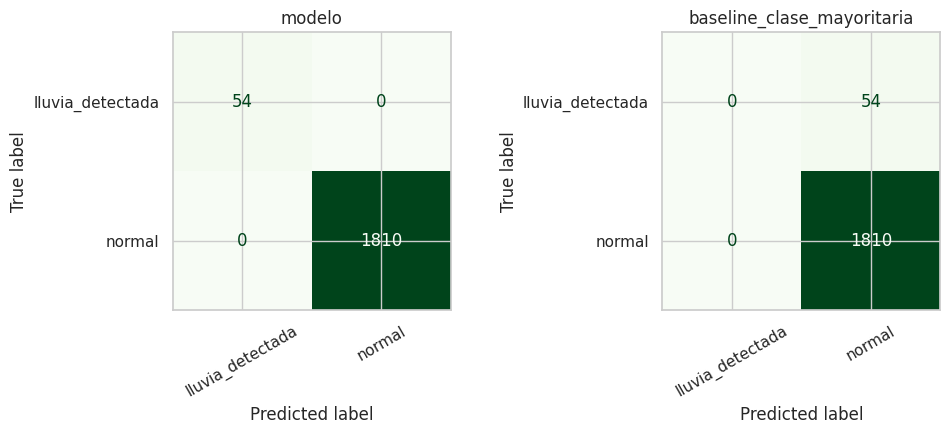

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4.5))
labels = resultado_rf["modelo"]["labels"]
for ax, clave in zip(axes, ["modelo", "baseline_clase_mayoritaria"]):
    cm = np.array(resultado_rf[clave]["matriz_confusion"])
    ConfusionMatrixDisplay(cm, display_labels=labels).plot(ax=ax, cmap="Greens", colorbar=False, xticks_rotation=30)
    ax.set_title(clave)
fig.tight_layout()
plt.show()


**Lectura honesta:** el modelo sí supera claramente al baseline (F1 macro 1.00 vs 0.49) --
pero, como ya se advirtió en el paso 7, esto en gran parte refleja que `_tipo_anomalia` lo genera
el propio motor de reglas de umbral a partir de las mismas variables que ve el clasificador. El
baseline de "clase mayoritaria" falla porque nunca predice `lluvia_detectada` (recall 0 para esa
clase) -- comparar contra él sigue siendo útil para confirmar que el modelo no es solo "accuracy
alta porque casi todo es normal" (accuracy engañosa), que es justo el riesgo que este tipo de
comparación está diseñada para exponer.

## Sección C — Predicción de lluvia (Algoritmo Genético)

**Segundo hallazgo honesto de esta evaluación:** los números agregados del AG se ven muy bien,
pero hay que mirar la matriz de confusión para entender por qué.

In [8]:
resultado_ga = ev.evaluar_ga_lluvia(train, test, artefactos["ga_lluvia"], horas=3)
tabla_ga = pd.DataFrame({
    k: {"accuracy": v["accuracy"], "precision": v["precision"], "recall": v["recall"], "f1": v["f1"]}
    for k, v in resultado_ga.items() if isinstance(v, dict)
}).T.round(3)
tabla_ga


,accuracy,precision,recall,f1
modelo,0.783,0.783,1.00,0.879
baseline_clase_mayoritaria,0.217,0.000,0.00,0.000
baseline_persistencia,0.255,0.981,0.05,0.095


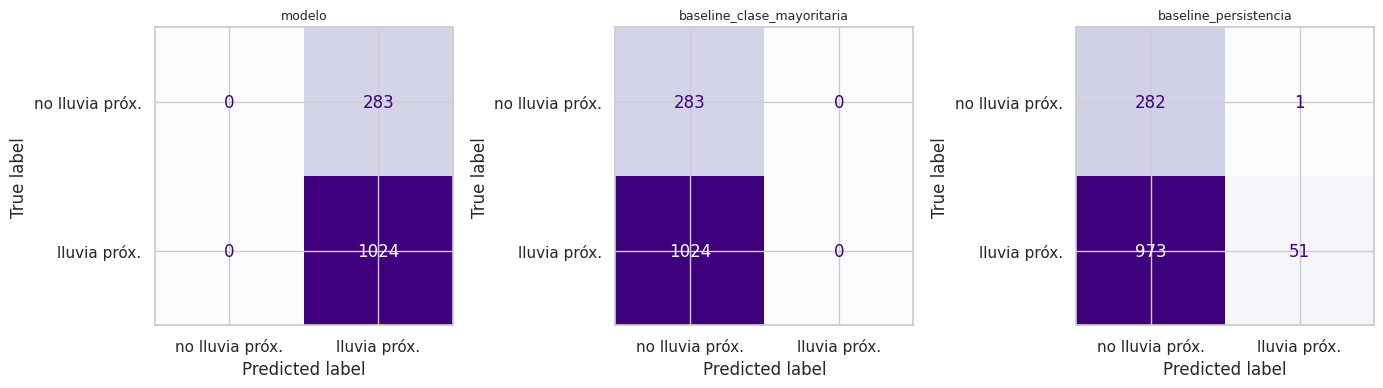

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4.5))
claves_ga = [k for k in resultado_ga if isinstance(resultado_ga[k], dict)]
for ax, nombre in zip(axes, claves_ga):
    cm = np.array(resultado_ga[nombre]["matriz_confusion"])
    ConfusionMatrixDisplay(cm, display_labels=["no lluvia próx.", "lluvia próx."]).plot(ax=ax, cmap="Purples", colorbar=False)
    ax.set_title(nombre, fontsize=9)
fig.tight_layout()
plt.show()


**Lectura honesta de la matriz de confusión del modelo:** la columna de "predijo NO lluvia"
está completamente vacía -- el AG predijo **"riesgo de lluvia" para las 1,307 filas de test, sin
excepción**. Esto no es una coincidencia positiva: el tramo de test evaluado resultó estar
dominado por el período previo a un evento de lluvia real (78% de las filas tienen la etiqueta
positiva), así que el AG obtiene un F1 alto en gran parte porque "casi siempre acertar prediciendo
lluvia" ya es una buena estrategia EN ESTE tramo particular de test -- no porque haya aprendido a
distinguir con precisión cuándo NO va a llover.

El baseline de persistencia (predecir "seguirá como está ahora mismo") expone esto mejor: tiene
precisión altísima pero recall pésimo -- es demasiado conservador. El AG no es igual de degenerado
que el baseline de mayoría, pero **su buen desempeño aquí está inflado por el desbalance de este
tramo de test específico**, no confirmado como generalización robusta.

**Recomendación:** repetir esta evaluación cuando existan más eventos de lluvia reales
distribuidos en distintos tramos de tiempo -- con un solo evento grande dominando el test actual,
esta métrica no es concluyente todavía.

## Sección D — Tiempo restante de secado (regresión) — bloqueado

In [10]:
resultado_tiempo = ev.evaluar_tiempo_restante(test)
print(resultado_tiempo)


{'omitido': 'solo 0 lote(s) en test con horas_restantes conocida; se necesitan al menos 5 lotes finalizados para evaluar con RMSE/MAE.', 'baseline_propuesto': 'predecir siempre DURACION_HORAS_PROMEDIO[tipo_proceso] - horas_transcurridas (duración típica del Cuadro 1, sin usar ninguna lectura de sensor)'}


## Sección E — Calidad final (clasificación) — bloqueado

In [11]:
resultado_calidad = ev.evaluar_calidad(test)
print(resultado_calidad)


{'omitido': 'la columna _calidad_final_lote no existe en este dataset (retroalimentacion_ml sigue vacía en Neon).'}


## Sección F — Recomendaciones (verificación de cobertura, no métricas de ML)

In [12]:
resultado_cobertura = ev.evaluar_cobertura_recomendaciones(pd.concat([train, test]))
resultado_cobertura


{'tipos_de_anomalia_observados': ['lluvia_detectada',
  'normal',
  'temperatura_alta'],
 'cubiertos_por_rules_py': ['lluvia_detectada', 'normal', 'temperatura_alta'],
 'faltantes': [],
 'cobertura_completa': True}

**Lectura:** todos los tipos de anomalía observados en los datos reales tienen una
recomendación definida en `app/services/rules.py` -- cobertura completa. Esta verificación debería
volver a correrse cada vez que aparezca un tipo de anomalía nuevo en producción.

## Resumen final

| Salida | Métrica del modelo | Métrica del mejor baseline | ¿Aporta valor real? |
|---|---|---|---|
| Anomalías (IsolationForest) | F1 = 0.000 | F1 = 0.000 (empate) | **No todavía** — descalibrado, requiere ajustar `contamination` |
| Tipo de anomalía (RandomForest) | F1 macro = 1.00 | F1 macro = 0.49 | Sí, aunque con la salvedad de etiquetas rule-derived |
| Lluvia próxima (AG) | F1 = 0.88 | F1 = 0.09 (persistencia) | Parcial — resultado inflado por desbalance de este test, revisar con más eventos |
| Tiempo restante | — | — | Bloqueado (0 lotes finalizados) |
| Calidad final | — | — | Bloqueado (0 retroalimentación real) |
| Recomendaciones | Cobertura 100% | — | Sí (verificación de cobertura, no de ML) |

## Conclusiones y siguiente paso

- Esta evaluación **no fue un trámite** -- encontró un problema real (IsolationForest
  descalibrado tras crecer el dataset) que el paso 7 no había mostrado, y matizó un resultado que
  se veía perfecto (el AG de lluvia) explicando por qué su métrica agregada es engañosa en este
  tramo de test específico.
- Antes de considerar cualquiera de estos modelos listo para el servicio en producción, hace falta:
  1. Cambiar `contamination` del IsolationForest a `"auto"` (o recalcularlo dinámicamente) y
     volver a entrenar/evaluar.
  2. Acumular más eventos de lluvia reales distribuidos en el tiempo antes de confiar en la
     métrica del AG.
  3. Seguir acumulando lotes finalizados y retroalimentación real para poder siquiera empezar a
     evaluar tiempo restante y calidad.
- **Siguiente paso natural:** paso 10, ajuste de hiperparámetros -- pero primero vale la pena
  resolver el punto 1 (contamination) porque ajustar hiperparámetros sobre un modelo mal
  calibrado por diseño no serviría de mucho.
